<a href="https://colab.research.google.com/github/stefanogiagu/corso_AML_2026/blob/main/AML_multimodal_Exercises_CLIP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CLIP
CLIP is a neural network adept at grasping visual concepts through natural language supervision. It operates by concurrently training a text encoder and an image encoder, focusing on a pretraining task that involves matching captions with corresponding images. This architecture allows CLIP to adapt to a variety of visual classification benchmarks seamlessly. It does so by simply receiving the names of the visual categories to be recognized, demonstrating “zero-shot” learning capabilities

In [1]:
from PIL import Image
import requests

from transformers import CLIPProcessor, CLIPModel

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

In [9]:
url = "http://images.cocodataset.org/val2017/000000039769.jpg"
image = Image.open(requests.get(url, stream=True).raw)
caption_list = ["a photo of a cat", "a photo of a dog"]
inputs = processor(
    text=caption_list,
    images=image,
    return_tensors="pt",
    padding=True,
)

outputs = model(**inputs)
logits_per_image = outputs.logits_per_image
probs = logits_per_image.softmax(dim=1)

In [7]:
# this is input format, see the tokenization of multimodal input
inputs.keys()

KeysView({'pixel_values': tensor([[[[ 0.5873,  0.5873,  0.6165,  ...,  0.0617,  0.0471, -0.0259],
          [ 0.5727,  0.5727,  0.6603,  ...,  0.1201,  0.0763,  0.0909],
          [ 0.5873,  0.5435,  0.6165,  ...,  0.0325,  0.1201,  0.0617],
          ...,
          [ 1.8719,  1.8573,  1.8719,  ...,  1.3902,  1.4340,  1.4194],
          [ 1.8281,  1.8719,  1.8427,  ...,  1.4486,  1.4340,  1.5070],
          [ 1.8573,  1.9011,  1.8281,  ...,  1.3756,  1.3610,  1.4486]],

         [[-1.3169, -1.3019, -1.3169,  ..., -1.4970, -1.4369, -1.4820],
          [-1.2418, -1.2718, -1.2268,  ..., -1.4369, -1.4669, -1.4519],
          [-1.2568, -1.3169, -1.2268,  ..., -1.4669, -1.4069, -1.4519],
          ...,
          [ 0.1239,  0.1089,  0.1239,  ..., -0.7016, -0.6865, -0.6865],
          [ 0.0789,  0.0939,  0.0488,  ..., -0.6565, -0.6865, -0.6115],
          [ 0.0939,  0.1089,  0.0038,  ..., -0.7766, -0.7316, -0.6115]],

         [[-0.4848, -0.4137, -0.3853,  ..., -0.9541, -0.8545, -0.8545],
    

In [12]:
probs

tensor([[0.9948, 0.0052]], grad_fn=<SoftmaxBackward0>)

a photo of a cat 0.99
a photo of a dog 0.01


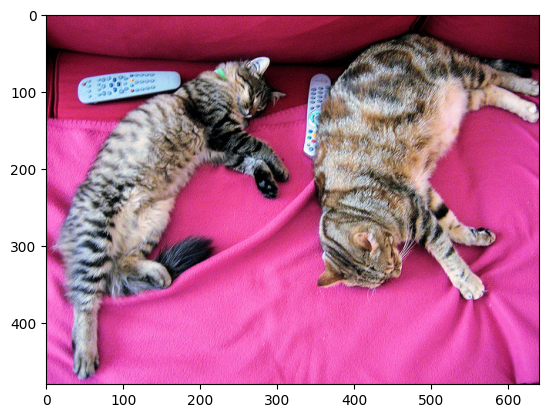

In [17]:
import matplotlib.pyplot as plt
import numpy as np
plt.imshow(np.asarray(image))
#nice formatting
for i,s in enumerate(caption_list):
 print(s, round(probs[0,i].item(),2))

In [ ]:
#comprension is quite high, probability are normalized.
#If a more "fitting" alternative is presented, the model shift the weigth in favour of the more detailed description

In [28]:
url = "https://5.imimg.com/data5/DJ/PV/GLADMIN-64970456/computer-lab-class.png"

image = Image.open(requests.get(url, stream=True).raw)
caption_list = ["a computer lab", "a classroom", "a strip club"]
inputs = processor(
    text=caption_list,
    images=image,
    return_tensors="pt",
    padding=True,
)

outputs = model(**inputs)
logits_per_image = outputs.logits_per_image
probs = logits_per_image.softmax(dim=1)

a computer lab 0.92
a classroom 0.08
a strip club 0.0


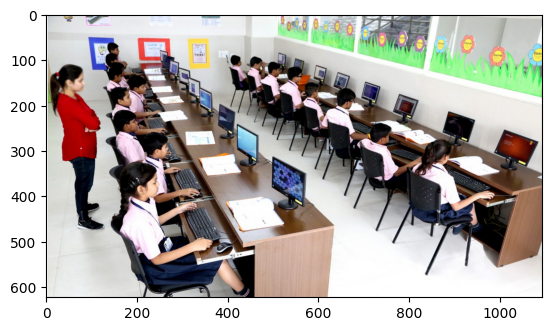

In [29]:
plt.imshow(np.asarray(image))
#nice formatting
for i,s in enumerate(caption_list):
 print(s, round(probs[0,i].item(),2))

In [30]:
caption_list = [ "a computer lab","two lines of students sitted with computers","two lines of students","sitted with computers"]
inputs = processor(
    text=caption_list,
    images=image,
    return_tensors="pt",
    padding=True,
)

outputs = model(**inputs)
logits_per_image = outputs.logits_per_image
probs = logits_per_image.softmax(dim=1)

two lines of students sitted with computers 0.97
two lines of students 0.0
sitted with computers 0.01
a computer lab 0.02


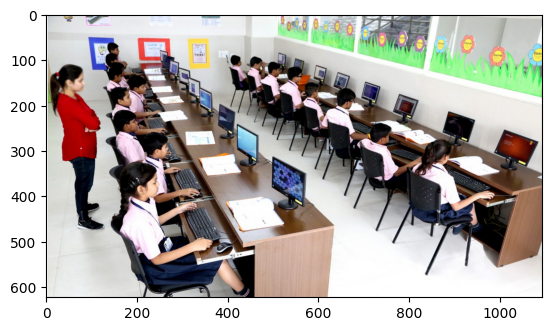

In [31]:
plt.imshow(np.asarray(image))
#nice formatting
for i,s in enumerate(caption_list):
 print(s, round(probs[0,i].item(),2))

In [36]:
caption_list = ["two lines of students sitted with computers", "two lines of asian students sitted with computers","two lines of black students sitted with computers","two lines of indian students sitted with computers"]
inputs = processor(
    text=caption_list,
    images=image,
    return_tensors="pt",
    padding=True,
)

outputs = model(**inputs)
logits_per_image = outputs.logits_per_image
probs = logits_per_image.softmax(dim=1)

two lines of students sitted with computers 0.18
two lines of asian students sitted with computers 0.3
two lines of black students sitted with computers 0.02
two lines of indian students sitted with computers 0.49


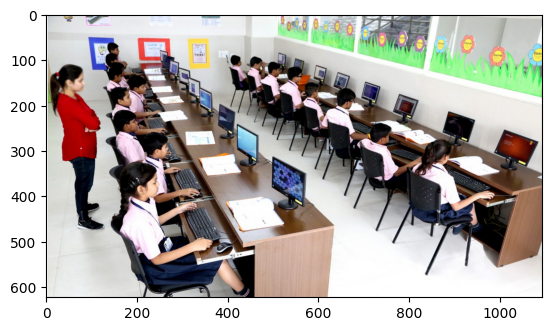

In [37]:
plt.imshow(np.asarray(image))
#nice formatting
for i,s in enumerate(caption_list):
 print(s, round(probs[0,i].item(),2))